# **Data-Driven Weather Analysis: Understanding Climate Variability Through Analytics**

## Project Overview
This project analyzes daily weather observations for **10 Indian cities from 2021–2025**. The analysis focuses on temperature, humidity, wind speed, atmospheric pressure, solar radiation, precipitation, and derived weather categories.

### Project objectives
1. Understand and clean the weather dataset.
2. Explore weather patterns across cities and years.
3. Analyze seasonal and monthly variation.
4. Compare temperature, rainfall, humidity, wind speed, and solar radiation across locations.
5. Identify relationships between weather variables.
6. Create meaningful visualizations using **Matplotlib, Seaborn, and Plotly**.
7. Summarize actionable analytical insights.

# TASK 1 — Problem Definition & Dataset Understanding

## Problem Statement
Weather conditions vary considerably across Indian cities and seasons. This project uses historical daily weather data to identify temperature, rainfall, humidity, wind, and seasonal patterns and to compare weather conditions across different locations.

In [1]:
# Import required libraries

import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Plotly is used for interactive visualizations
import plotly.express as px
import plotly.graph_objects as go

from IPython.display import display

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
# Visual theme for a polished project presentation

# Consistent palette used across static charts
PROJECT_COLORS = {
    "primary": "#2563EB",
    "secondary": "#0EA5E9",
    "accent": "#F59E0B",
    "success": "#10B981",
    "danger": "#EF4444",
    "purple": "#8B5CF6",
    "dark": "#1E293B",
    "light": "#F8FAFC"
}

sns.set_theme(
    style="whitegrid",
    context="notebook",
    font_scale=1.05
)

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "#F8FAFC",
    "axes.edgecolor": "#CBD5E1",
    "axes.titleweight": "bold",
    "axes.titlesize": 15,
    "axes.labelsize": 11,
    "axes.titlepad": 14,
    "figure.titlesize": 17,
    "legend.frameon": False
})

print("Visual theme applied successfully.")

Visual theme applied successfully.


In [3]:
# Load the dataset

file_path = "Weather_Dataset.csv"

if not os.path.exists(file_path):
    # Helpful fallback when the notebook is opened in the same environment
    file_path = "/mnt/data/Weather_Dataset.csv"

df = pd.read_csv(file_path)

print(f"Dataset shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
display(df.head())

Dataset shape: 18,260 rows × 12 columns


,Date,City,State,T2M,T2M_MAX,T2M_MIN,RH2M,WS2M,PS,ALLSKY_SFC_SW_DWN,PRECTOTCORR,Weather
0,01-01-2021,Bengaluru,Karnataka,18.87,25.42,14.85,81.29,2.95,91.92,17.97,0.16,Humid
1,02-01-2021,Bengaluru,Karnataka,19.86,26.40,14.14,84.14,2.71,91.89,14.42,0.29,Humid
2,03-01-2021,Bengaluru,Karnataka,20.95,27.02,16.48,82.54,2.92,91.78,11.15,0.15,Humid
3,04-01-2021,Bengaluru,Karnataka,21.01,27.06,17.10,80.60,3.27,91.78,7.46,0.06,Humid
4,05-01-2021,Bengaluru,Karnataka,20.98,26.13,16.89,86.53,2.57,91.82,14.06,0.48,Humid


In [4]:
# Basic dataset information

print("Data types:")
display(df.dtypes.to_frame("dtype"))

print("\nDataset information:")
df.info()

print("\nNumerical summary:")
display(df.describe().T)

Data types:


,dtype
Date,str
City,str
State,str
T2M,float64
T2M_MAX,float64
T2M_MIN,float64
RH2M,float64
WS2M,float64
PS,float64
ALLSKY_SFC_SW_DWN,float64



Dataset information:
<class 'pandas.DataFrame'>
RangeIndex: 18260 entries, 0 to 18259
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Date               18260 non-null  str    
 1   City               18260 non-null  str    
 2   State              14608 non-null  str    
 3   T2M                18260 non-null  float64
 4   T2M_MAX            18260 non-null  float64
 5   T2M_MIN            18260 non-null  float64
 6   RH2M               18260 non-null  float64
 7   WS2M               18260 non-null  float64
 8   PS                 18260 non-null  float64
 9   ALLSKY_SFC_SW_DWN  18260 non-null  float64
 10  PRECTOTCORR        18260 non-null  float64
 11  Weather            18260 non-null  str    
dtypes: float64(8), str(4)
memory usage: 1.7 MB

Numerical summary:


,count,mean,std,min,25%,50%,75%,max
T2M,"18,260.00",24.06,7.16,-9.47,21.19,26.04,28.46,41.23
T2M_MAX,"18,260.00",29.62,7.13,-2.81,27.19,30.10,33.57,48.50
T2M_MIN,"18,260.00",19.49,7.72,-17.58,15.41,21.91,25.24,35.13
RH2M,"18,260.00",67.78,18.89,6.00,56.34,72.87,82.79,96.15
WS2M,"18,260.00",2.10,1.12,0.18,1.36,1.90,2.70,11.28
PS,"18,260.00",95.35,7.53,73.26,95.24,97.28,100.15,101.95
ALLSKY_SFC_SW_DWN,"18,260.00",17.48,5.24,0.98,14.08,17.82,21.41,32.35
PRECTOTCORR,"18,260.00",4.40,10.43,0.00,0.00,0.21,4.12,238.99


In [5]:
# Categorical columns and unique values

categorical_cols = ["City", "State", "Weather"]

for col in categorical_cols:
    print(f"\n{col}:")
    print(df[col].value_counts(dropna=False))


City:
City
Bengaluru    1826
Chennai      1826
Delhi        1826
Guwahati     1826
Hyderabad    1826
Jaipur       1826
kochi        1826
Kolkata      1826
mumbai       1826
Srinagar     1826
Name: count, dtype: int64

State:
State
NaN                  3652
Karnataka            1826
Tamil Nadu           1826
Delhi                1826
Assam                1826
Telangana            1826
Rajasthan            1826
West Bengal          1826
Jammu and Kashmir    1826
Name: count, dtype: int64

Weather:
Weather
Normal         8486
Rainy          3678
Heavy Rain     2430
Humid          1918
Cold           1490
Hot & Dry       254
Hot & Humid       4
Name: count, dtype: int64


# TASK 2 — Data Cleaning & Pre-processing

The cleaning workflow checks:
- duplicate records
- missing values
- inconsistent city names
- date format
- numerical data types
- impossible/invalid values
- outliers
- chronological completeness

In [6]:
# Keep an untouched copy for comparison

df_raw = df.copy()

print("Original shape:", df_raw.shape)
print("Duplicate rows:", df_raw.duplicated().sum())

missing = df_raw.isna().sum().sort_values(ascending=False)
missing_pct = (df_raw.isna().mean() * 100).sort_values(ascending=False)

missing_report = pd.DataFrame({
    "Missing_Count": missing,
    "Missing_Percentage": missing_pct.round(2)
})

display(missing_report)

Original shape: (18260, 12)
Duplicate rows: 0


,Missing_Count,Missing_Percentage
State,3652,20.00
Date,0,0.00
City,0,0.00
T2M,0,0.00
T2M_MAX,0,0.00
T2M_MIN,0,0.00
RH2M,0,0.00
WS2M,0,0.00
PS,0,0.00
ALLSKY_SFC_SW_DWN,0,0.00


In [7]:
# Standardize column names and text fields

df_clean = df_raw.copy()

df_clean.columns = (
    df_clean.columns
    .str.strip()
    .str.replace(" ", "_")
)

for col in ["City", "State", "Weather"]:
    df_clean[col] = df_clean[col].astype("string").str.strip()

# Standardize city capitalization
df_clean["City"] = df_clean["City"].str.title()

# Standardize weather labels
df_clean["Weather"] = df_clean["Weather"].str.strip()

print("Unique cities after standardization:")
print(sorted(df_clean["City"].dropna().unique()))

Unique cities after standardization:
['Bengaluru', 'Chennai', 'Delhi', 'Guwahati', 'Hyderabad', 'Jaipur', 'Kochi', 'Kolkata', 'Mumbai', 'Srinagar']


In [8]:
# Convert Date into datetime

df_clean["Date"] = pd.to_datetime(
    df_clean["Date"],
    format="%d-%m-%Y",
    errors="coerce"
)

print("Invalid dates:", df_clean["Date"].isna().sum())
print("Date range:", df_clean["Date"].min().date(), "to", df_clean["Date"].max().date())

Invalid dates: 0
Date range: 2021-01-01 to 2025-12-31


In [9]:
# Check duplicate records after standardization

duplicate_count = df_clean.duplicated().sum()
print("Duplicate rows:", duplicate_count)

if duplicate_count > 0:
    df_clean = df_clean.drop_duplicates().copy()

print("Shape after duplicate handling:", df_clean.shape)

Duplicate rows: 0
Shape after duplicate handling: (18260, 12)


In [10]:
# Check missing State values and repair them using the city-state relationship

print("Missing State values before imputation:", df_clean["State"].isna().sum())

# Build a verified city -> state mapping from rows where State is present
city_state_map = (
    df_clean.dropna(subset=["State"])
    .groupby("City")["State"]
    .agg(lambda x: x.mode().iat[0] if not x.mode().empty else x.iloc[0])
    .to_dict()
)

df_clean["State"] = df_clean["State"].fillna(df_clean["City"].map(city_state_map))

print("Missing State values after city-based imputation:", df_clean["State"].isna().sum())

state_check = (
    df_clean.groupby("City")["State"]
    .agg(["count", "nunique", "first"])
    .sort_index()
)
display(state_check)

Missing State values before imputation: 3652
Missing State values after city-based imputation: 3652


,count,nunique,first
City,,,
Bengaluru,1826,1,Karnataka
Chennai,1826,1,Tamil Nadu
Delhi,1826,1,Delhi
Guwahati,1826,1,Assam
Hyderabad,1826,1,Telangana
Jaipur,1826,1,Rajasthan
Kochi,0,0,<NA>
Kolkata,1826,1,West Bengal
Mumbai,0,0,<NA>


In [11]:
# Validate numerical columns

numeric_cols = [
    "T2M", "T2M_MAX", "T2M_MIN", "RH2M", "WS2M",
    "PS", "ALLSKY_SFC_SW_DWN", "PRECTOTCORR"
]

for col in numeric_cols:
    df_clean[col] = pd.to_numeric(df_clean[col], errors="coerce")

# Count missing values after conversion
display(df_clean[numeric_cols].isna().sum().to_frame("Missing_Count"))

,Missing_Count
T2M,0
T2M_MAX,0
T2M_MIN,0
RH2M,0
WS2M,0
PS,0
ALLSKY_SFC_SW_DWN,0
PRECTOTCORR,0


In [12]:
# Validate logical and physical ranges

range_checks = {
    "T2M": (None, None),
    "T2M_MAX": (None, None),
    "T2M_MIN": (None, None),
    "RH2M": (0, 100),
    "WS2M": (0, None),
    "PS": (0, None),
    "ALLSKY_SFC_SW_DWN": (0, None),
    "PRECTOTCORR": (0, None)
}

for col, (lower, upper) in range_checks.items():
    invalid = pd.Series(False, index=df_clean.index)
    if lower is not None:
        invalid |= df_clean[col] < lower
    if upper is not None:
        invalid |= df_clean[col] > upper
    print(f"{col}: {invalid.sum()} invalid values")

# Temperature consistency checks
print("T2M_MAX < T2M count:", (df_clean["T2M_MAX"] < df_clean["T2M"]).sum())
print("T2M_MIN > T2M count:", (df_clean["T2M_MIN"] > df_clean["T2M"]).sum())
print("T2M_MIN > T2M_MAX count:", (df_clean["T2M_MIN"] > df_clean["T2M_MAX"]).sum())

T2M: 0 invalid values
T2M_MAX: 0 invalid values
T2M_MIN: 0 invalid values
RH2M: 0 invalid values
WS2M: 0 invalid values
PS: 0 invalid values
ALLSKY_SFC_SW_DWN: 0 invalid values
PRECTOTCORR: 0 invalid values
T2M_MAX < T2M count: 0
T2M_MIN > T2M count: 0
T2M_MIN > T2M_MAX count: 0


In [13]:
# Missing-value treatment

# Numerical weather variables: use city-level median because weather distributions
# differ substantially by location.
for col in numeric_cols:
    if df_clean[col].isna().any():
        df_clean[col] = df_clean.groupby("City")[col].transform(
            lambda s: s.fillna(s.median())
        )
        df_clean[col] = df_clean[col].fillna(df_clean[col].median())

# Categorical fields: use the most frequent value where needed.
for col in ["State", "Weather"]:
    if df_clean[col].isna().any():
        df_clean[col] = df_clean[col].fillna(df_clean[col].mode()[0])

print("Remaining missing values:")
display(df_clean.isna().sum().to_frame("Missing_Count"))

Remaining missing values:


,Missing_Count
Date,0
City,0
State,0
T2M,0
T2M_MAX,0
T2M_MIN,0
RH2M,0
WS2M,0
PS,0
ALLSKY_SFC_SW_DWN,0


In [14]:
# Check date continuity for each city

expected_days = pd.date_range(
    df_clean["Date"].min(),
    df_clean["Date"].max(),
    freq="D"
)

continuity_report = []

for city, group in df_clean.groupby("City"):
    unique_dates = pd.DatetimeIndex(group["Date"].dropna().unique()).sort_values()
    missing_days = len(expected_days.difference(unique_dates))
    continuity_report.append({
        "City": city,
        "Rows": len(group),
        "Unique_Dates": group["Date"].nunique(),
        "Missing_Dates": missing_days
    })

continuity_report = pd.DataFrame(continuity_report).sort_values("City")
display(continuity_report)

,City,Rows,Unique_Dates,Missing_Dates
0,Bengaluru,1826,1826,0
1,Chennai,1826,1826,0
2,Delhi,1826,1826,0
3,Guwahati,1826,1826,0
4,Hyderabad,1826,1826,0
5,Jaipur,1826,1826,0
6,Kochi,1826,1826,0
7,Kolkata,1826,1826,0
8,Mumbai,1826,1826,0
9,Srinagar,1826,1826,0


In [15]:
# Detect outliers using the IQR method

outlier_summary = []

for col in numeric_cols:
    q1 = df_clean[col].quantile(0.25)
    q3 = df_clean[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    count = ((df_clean[col] < lower) | (df_clean[col] > upper)).sum()

    outlier_summary.append({
        "Variable": col,
        "Q1": q1,
        "Q3": q3,
        "Lower_Bound": lower,
        "Upper_Bound": upper,
        "Outlier_Count": count,
        "Outlier_Percentage": count / len(df_clean) * 100
    })

outlier_summary = pd.DataFrame(outlier_summary)
display(outlier_summary.round(2))

print(
    "Outliers are retained for analysis because extreme weather values can be",
    "genuine observations rather than data-entry errors."
)

,Variable,Q1,Q3,Lower_Bound,Upper_Bound,Outlier_Count,Outlier_Percentage
0,T2M,21.19,28.46,10.29,39.36,979,5.36
1,T2M_MAX,27.19,33.57,17.62,43.14,1272,6.97
2,T2M_MIN,15.41,25.24,0.66,39.99,620,3.40
3,RH2M,56.34,82.79,16.66,122.46,192,1.05
4,WS2M,1.36,2.70,-0.65,4.71,511,2.80
5,PS,95.24,100.15,87.87,107.52,1826,10.00
6,ALLSKY_SFC_SW_DWN,14.08,21.41,3.08,32.40,67,0.37
7,PRECTOTCORR,0.00,4.12,-6.18,10.30,2367,12.96


Outliers are retained for analysis because extreme weather values can be genuine observations rather than data-entry errors.


## Feature Engineering

Additional time and weather features are created for analysis:
- Year
- Month number and month name
- Season
- Temperature range
- Rainy-day flag
- Heavy-rain flag
- Temperature category


In [16]:
# Create analytical features

df_clean["Year"] = df_clean["Date"].dt.year
df_clean["Month"] = df_clean["Date"].dt.month
df_clean["Month_Name"] = df_clean["Date"].dt.month_name().str[:3]
df_clean["Day"] = df_clean["Date"].dt.day
df_clean["Day_of_Year"] = df_clean["Date"].dt.dayofyear

# Meteorological-style seasons for India
def get_season(month):
    if month in [12, 1, 2]:
        return "Winter"
    elif month in [3, 4, 5]:
        return "Summer"
    elif month in [6, 7, 8, 9]:
        return "Monsoon"
    else:
        return "Post-Monsoon"

df_clean["Season"] = df_clean["Month"].apply(get_season)

df_clean["Temperature_Range"] = df_clean["T2M_MAX"] - df_clean["T2M_MIN"]

df_clean["Rainy_Day"] = np.where(df_clean["PRECTOTCORR"] >= 2.5, "Yes", "No")
df_clean["Heavy_Rain_Day"] = np.where(df_clean["PRECTOTCORR"] >= 20, "Yes", "No")

df_clean["Temperature_Category"] = pd.cut(
    df_clean["T2M"],
    bins=[-np.inf, 15, 25, 35, np.inf],
    labels=["Cold", "Moderate", "Warm", "Very Warm"]
)

display(df_clean.head())

,Date,City,State,T2M,T2M_MAX,T2M_MIN,RH2M,WS2M,PS,ALLSKY_SFC_SW_DWN,PRECTOTCORR,Weather,Year,Month,Month_Name,Day,Day_of_Year,Season,Temperature_Range,Rainy_Day,Heavy_Rain_Day,Temperature_Category
0,2021-01-01,Bengaluru,Karnataka,18.87,25.42,14.85,81.29,2.95,91.92,17.97,0.16,Humid,2021,1,Jan,1,1,Winter,10.57,No,No,Moderate
1,2021-01-02,Bengaluru,Karnataka,19.86,26.40,14.14,84.14,2.71,91.89,14.42,0.29,Humid,2021,1,Jan,2,2,Winter,12.26,No,No,Moderate
2,2021-01-03,Bengaluru,Karnataka,20.95,27.02,16.48,82.54,2.92,91.78,11.15,0.15,Humid,2021,1,Jan,3,3,Winter,10.54,No,No,Moderate
3,2021-01-04,Bengaluru,Karnataka,21.01,27.06,17.10,80.60,3.27,91.78,7.46,0.06,Humid,2021,1,Jan,4,4,Winter,9.96,No,No,Moderate
4,2021-01-05,Bengaluru,Karnataka,20.98,26.13,16.89,86.53,2.57,91.82,14.06,0.48,Humid,2021,1,Jan,5,5,Winter,9.24,No,No,Moderate


In [17]:
# Final cleaning validation

print("Final shape:", df_clean.shape)
print("Total missing values:", df_clean.isna().sum().sum())
print("Duplicate rows:", df_clean.duplicated().sum())

display(df_clean.describe(include="all").T)

Final shape: (18260, 22)
Total missing values: 0
Duplicate rows: 0


,count,unique,top,freq,mean,min,25%,50%,75%,max,std
Date,18260,NaN,NaN,NaN,2023-07-02 12:00:00,2021-01-01 00:00:00,2022-04-02 00:00:00,2023-07-02 12:00:00,2024-10-01 00:00:00,2025-12-31 00:00:00,NaN
City,18260,10,Bengaluru,1826,NaN,NaN,NaN,NaN,NaN,NaN,NaN
State,18260,8,Assam,5478,NaN,NaN,NaN,NaN,NaN,NaN,NaN
T2M,"18,260.00",NaN,NaN,NaN,24.06,-9.47,21.19,26.04,28.46,41.23,7.16
T2M_MAX,"18,260.00",NaN,NaN,NaN,29.62,-2.81,27.19,30.10,33.57,48.50,7.13
T2M_MIN,"18,260.00",NaN,NaN,NaN,19.49,-17.58,15.41,21.91,25.24,35.13,7.72
RH2M,"18,260.00",NaN,NaN,NaN,67.78,6.00,56.34,72.87,82.79,96.15,18.89
WS2M,"18,260.00",NaN,NaN,NaN,2.10,0.18,1.36,1.90,2.70,11.28,1.12
PS,"18,260.00",NaN,NaN,NaN,95.35,73.26,95.24,97.28,100.15,101.95,7.53
ALLSKY_SFC_SW_DWN,"18,260.00",NaN,NaN,NaN,17.48,0.98,14.08,17.82,21.41,32.35,5.24


## Weather Analytics Snapshot

Before the detailed EDA, we create a compact KPI-style overview of the dataset.


In [18]:
# KPI-style overview

from IPython.display import HTML, display

total_records = len(df_clean)
total_cities = df_clean["City"].nunique()
date_range_days = df_clean["Date"].nunique()
avg_temp = df_clean["T2M"].mean()
total_rain = df_clean["PRECTOTCORR"].sum()
avg_humidity = df_clean["RH2M"].mean()

kpi_html = f'''
<div style="
display:grid;
grid-template-columns:repeat(3, 1fr);
gap:14px;
margin:12px 0 24px 0;
font-family:Arial,sans-serif;
">
  <div style="background:#EFF6FF;padding:20px;border-radius:14px;border-left:5px solid #2563EB;">
    <div style="font-size:13px;color:#64748B;">Total records</div>
    <div style="font-size:28px;font-weight:700;color:#1E3A8A;">{total_records:,}</div>
  </div>
  <div style="background:#ECFEFF;padding:20px;border-radius:14px;border-left:5px solid #0EA5E9;">
    <div style="font-size:13px;color:#64748B;">Cities analyzed</div>
    <div style="font-size:28px;font-weight:700;color:#0C4A6E;">{total_cities}</div>
  </div>
  <div style="background:#F0FDF4;padding:20px;border-radius:14px;border-left:5px solid #10B981;">
    <div style="font-size:13px;color:#64748B;">Days covered</div>
    <div style="font-size:28px;font-weight:700;color:#166534;">{date_range_days:,}</div>
  </div>
  <div style="background:#FFF7ED;padding:20px;border-radius:14px;border-left:5px solid #F59E0B;">
    <div style="font-size:13px;color:#64748B;">Average temperature</div>
    <div style="font-size:28px;font-weight:700;color:#92400E;">{avg_temp:.1f} °C</div>
  </div>
  <div style="background:#F5F3FF;padding:20px;border-radius:14px;border-left:5px solid #8B5CF6;">
    <div style="font-size:13px;color:#5B21B6;">Total precipitation</div>
    <div style="font-size:28px;font-weight:700;color:#5B21B6;">{total_rain:,.0f} mm</div>
  </div>
  <div style="background:#FDF2F8;padding:20px;border-radius:14px;border-left:5px solid #EC4899;">
    <div style="font-size:13px;color:#9D174D;">Average humidity</div>
    <div style="font-size:28px;font-weight:700;color:#9D174D;">{avg_humidity:.1f}%</div>
  </div>
</div>
'''

display(HTML(kpi_html))


# TASK 3 — Exploratory Data Analysis

Investigate the cleaned dataset using summary statistics and grouped analysis.


In [19]:
# Overall descriptive statistics

display(df_clean[numeric_cols].describe().T)

print("\nNumber of cities:", df_clean["City"].nunique())
print("Number of states:", df_clean["State"].nunique())
print("Number of years:", df_clean["Year"].nunique())
print("Weather categories:", df_clean["Weather"].nunique())

,count,mean,std,min,25%,50%,75%,max
T2M,"18,260.00",24.06,7.16,-9.47,21.19,26.04,28.46,41.23
T2M_MAX,"18,260.00",29.62,7.13,-2.81,27.19,30.10,33.57,48.50
T2M_MIN,"18,260.00",19.49,7.72,-17.58,15.41,21.91,25.24,35.13
RH2M,"18,260.00",67.78,18.89,6.00,56.34,72.87,82.79,96.15
WS2M,"18,260.00",2.10,1.12,0.18,1.36,1.90,2.70,11.28
PS,"18,260.00",95.35,7.53,73.26,95.24,97.28,100.15,101.95
ALLSKY_SFC_SW_DWN,"18,260.00",17.48,5.24,0.98,14.08,17.82,21.41,32.35
PRECTOTCORR,"18,260.00",4.40,10.43,0.00,0.00,0.21,4.12,238.99



Number of cities: 10
Number of states: 8
Number of years: 5
Weather categories: 7


In [20]:
# City-level weather summary

city_summary = (
    df_clean.groupby(["City", "State"])
    .agg(
        Avg_Temperature=("T2M", "mean"),
        Max_Temperature=("T2M_MAX", "max"),
        Min_Temperature=("T2M_MIN", "min"),
        Avg_Humidity=("RH2M", "mean"),
        Avg_Wind_Speed=("WS2M", "mean"),
        Avg_Precipitation=("PRECTOTCORR", "mean"),
        Total_Precipitation=("PRECTOTCORR", "sum"),
        Avg_Solar_Radiation=("ALLSKY_SFC_SW_DWN", "mean")
    )
    .reset_index()
    .sort_values("Avg_Temperature", ascending=False)
)

display(city_summary.round(2))

,City,State,Avg_Temperature,Max_Temperature,Min_Temperature,Avg_Humidity,Avg_Wind_Speed,Avg_Precipitation,Total_Precipitation,Avg_Solar_Radiation
1,Chennai,Tamil Nadu,27.88,41.13,18.62,75.22,2.95,4.20,"7,671.82",18.10
6,Kochi,Assam,27.64,37.22,20.52,79.32,2.24,7.76,"14,174.44",18.74
8,Mumbai,Assam,26.83,44.11,9.49,69.59,2.52,8.35,"15,250.31",18.21
7,Kolkata,West Bengal,26.06,46.92,6.20,74.91,2.15,4.82,"8,796.98",15.54
4,Hyderabad,Telangana,25.73,43.88,8.32,65.61,2.46,2.81,"5,126.63",18.00
5,Jaipur,Rajasthan,25.07,47.84,1.48,50.96,2.10,2.43,"4,440.75",18.22
2,Delhi,Delhi,25.06,48.50,0.45,53.26,1.87,2.47,"4,509.96",16.76
0,Bengaluru,Karnataka,23.77,40.78,9.22,70.78,2.78,2.86,"5,222.33",18.74
3,Guwahati,Assam,23.11,39.00,5.86,77.32,0.54,5.39,"9,849.75",15.59
9,Srinagar,Jammu and Kashmir,9.40,29.97,-17.58,60.85,1.45,2.85,"5,210.48",16.91


In [21]:
# Annual city-level temperature and rainfall trends

annual_summary = (
    df_clean.groupby(["Year", "City"])
    .agg(
        Avg_Temperature=("T2M", "mean"),
        Total_Precipitation=("PRECTOTCORR", "sum"),
        Avg_Humidity=("RH2M", "mean")
    )
    .reset_index()
)

display(annual_summary.head(15).round(2))

,Year,City,Avg_Temperature,Total_Precipitation,Avg_Humidity
0,2021,Bengaluru,23.27,"1,173.87",73.60
1,2021,Chennai,27.61,"1,841.35",76.30
2,2021,Delhi,24.72,"1,045.35",53.76
3,2021,Guwahati,23.02,"1,680.98",77.87
4,2021,Hyderabad,25.40,"1,056.01",68.34
5,2021,Jaipur,25.21,835.11,49.94
6,2021,Kochi,27.29,"3,386.65",80.84
7,2021,Kolkata,26.11,"2,386.50",74.96
8,2021,Mumbai,26.88,"3,210.25",71.39
9,2021,Srinagar,8.90,"1,044.73",61.20


In [22]:
# Monthly overall climate summary

month_order = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
               "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

monthly_summary = (
    df_clean.groupby(["Month", "Month_Name"])
    .agg(
        Avg_Temperature=("T2M", "mean"),
        Avg_Max_Temperature=("T2M_MAX", "mean"),
        Avg_Min_Temperature=("T2M_MIN", "mean"),
        Avg_Humidity=("RH2M", "mean"),
        Avg_Precipitation=("PRECTOTCORR", "mean"),
        Total_Precipitation=("PRECTOTCORR", "sum"),
        Avg_Wind_Speed=("WS2M", "mean")
    )
    .reset_index()
    .sort_values("Month")

)
display(monthly_summary.round(2))

,Month,Month_Name,Avg_Temperature,Avg_Max_Temperature,Avg_Min_Temperature,Avg_Humidity,Avg_Precipitation,Total_Precipitation,Avg_Wind_Speed
0,1,Jan,17.47,24.23,12.22,66.03,0.94,"1,455.49",1.72
1,2,Feb,20.15,27.78,13.92,55.67,0.62,872.94,1.81
2,3,Mar,24.50,32.00,18.11,50.57,1.18,"1,823.76",1.98
3,4,Apr,27.90,34.86,21.77,50.35,1.93,"2,888.78",2.13
4,5,May,28.64,34.20,23.76,59.87,5.26,"8,153.28",2.41
5,6,Jun,28.27,32.84,24.31,68.20,7.16,"10,738.32",2.75
6,7,Jul,26.97,30.78,23.87,79.52,11.17,"17,308.55",2.87
7,8,Aug,26.17,29.87,23.19,82.65,8.21,"12,729.75",2.36
8,9,Sep,25.66,29.54,22.55,82.37,7.35,"11,028.70",2.08
9,10,Oct,23.81,28.54,20.03,76.91,4.52,"7,010.46",1.62


# TASK 4 — Data Visualization

### Matplotlib
Used for:
- Histogram
- Line plot
- Column chart
- Subplots

### Seaborn
Used for:
- Bar plot
- Scatter plot
- Box plot
- Pair plot
- Heatmap
- Violin plot

### Plotly
Used for:
- Interactive pie chart
- Interactive line chart
- Interactive scatter chart

Using all three libraries demonstrates both fundamental Python visualization skills and interactive dashboard-style visualization.


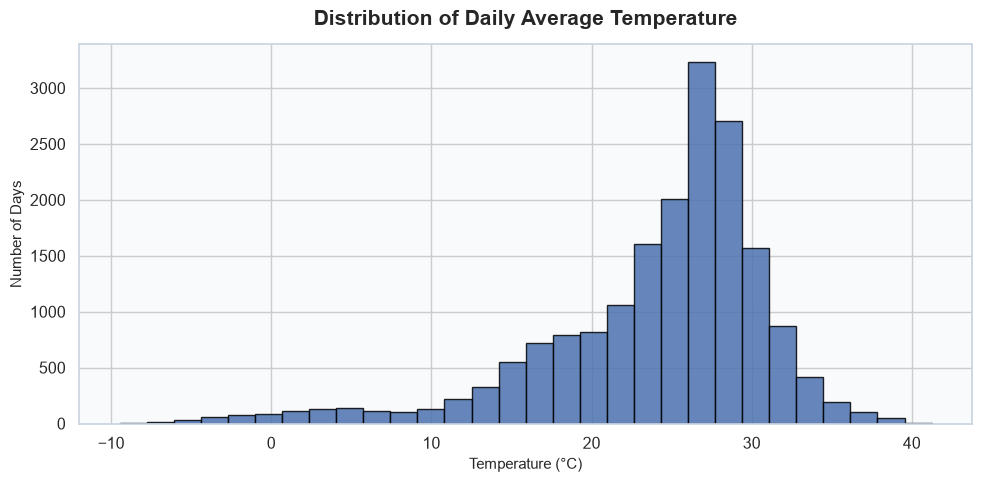

In [23]:
# 1. Histogram — Distribution of daily average temperature
plt.figure(figsize=(10, 5))
plt.hist(
    df_clean["T2M"],
    bins=30,
    edgecolor="black",
    alpha=0.85
)
plt.title("Distribution of Daily Average Temperature")
plt.xlabel("Temperature (°C)")
plt.ylabel("Number of Days")
plt.tight_layout()
plt.show()

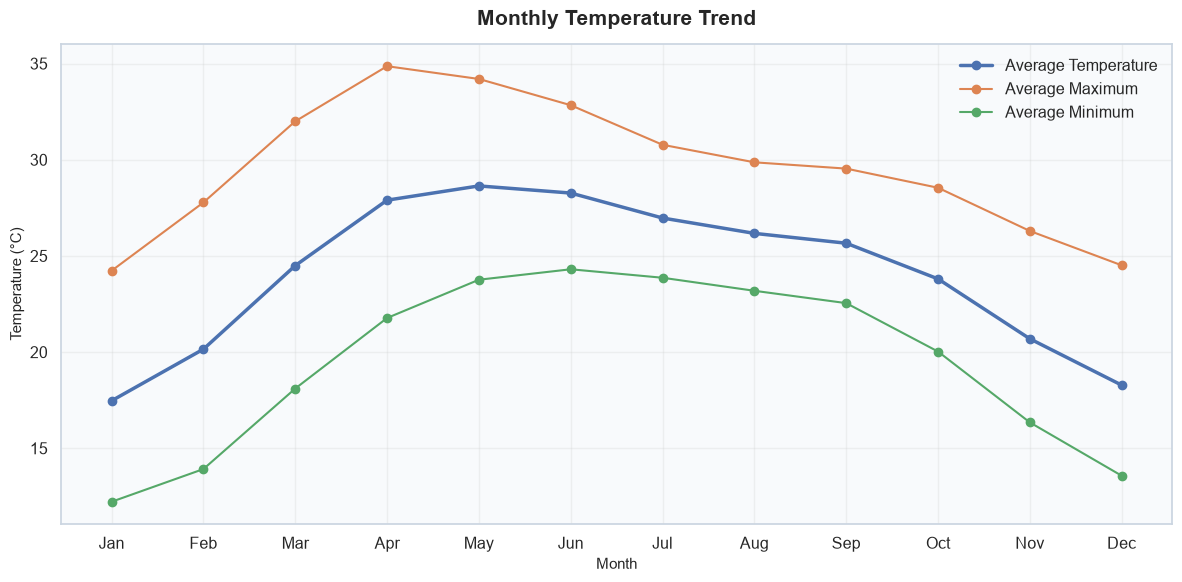

In [24]:
# 2 Monthly Temperature treand

plt.figure(figsize=(12, 6))
plt.plot(
    monthly_summary["Month_Name"],
    monthly_summary["Avg_Temperature"],
    marker="o",
    linewidth=2.5,
    label="Average Temperature"
)
plt.plot(
    monthly_summary["Month_Name"],
    monthly_summary["Avg_Max_Temperature"],
    marker="o",
    linewidth=1.5,
    label="Average Maximum"
)
plt.plot(
    monthly_summary["Month_Name"],
    monthly_summary["Avg_Min_Temperature"],
    marker="o",
    linewidth=1.5,
    label="Average Minimum"
)

plt.title("Monthly Temperature Trend")
plt.xlabel("Month")
plt.ylabel("Temperature (°C)")
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

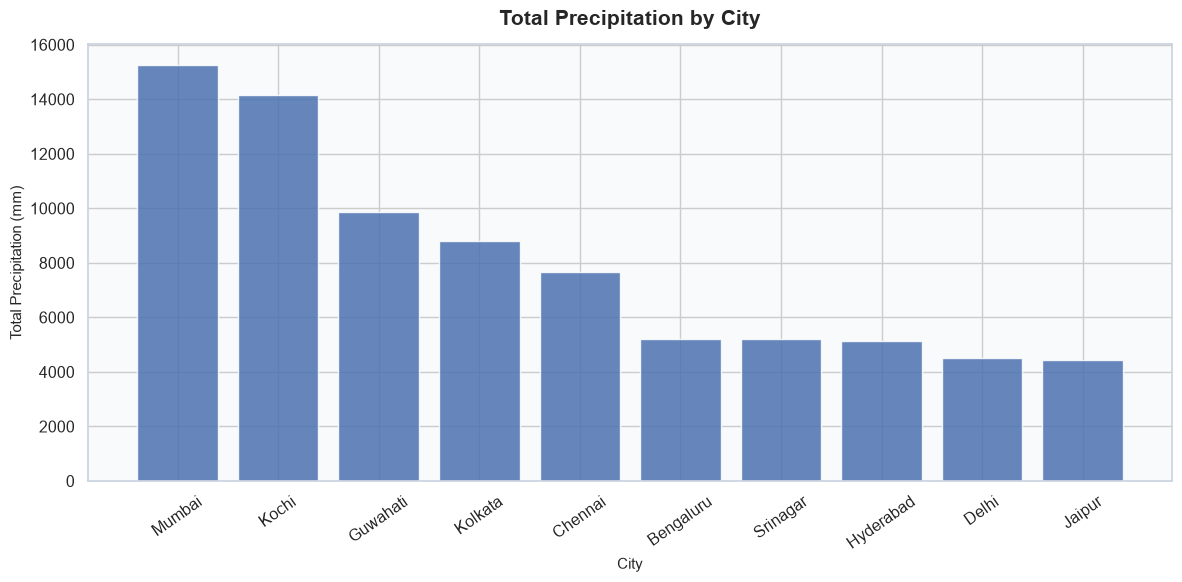

In [25]:
# 3 Total Precipitation by City

city_rain = (
    df_clean.groupby("City", as_index=False)["PRECTOTCORR"]
    .sum()
    .sort_values("PRECTOTCORR", ascending=False)
)

plt.figure(figsize=(12, 6))
plt.bar(
    city_rain["City"],
    city_rain["PRECTOTCORR"],
    alpha=0.85
)
plt.title("Total Precipitation by City")
plt.xlabel("City")
plt.ylabel("Total Precipitation (mm)")
plt.xticks(rotation=35)
plt.tight_layout()
plt.show()

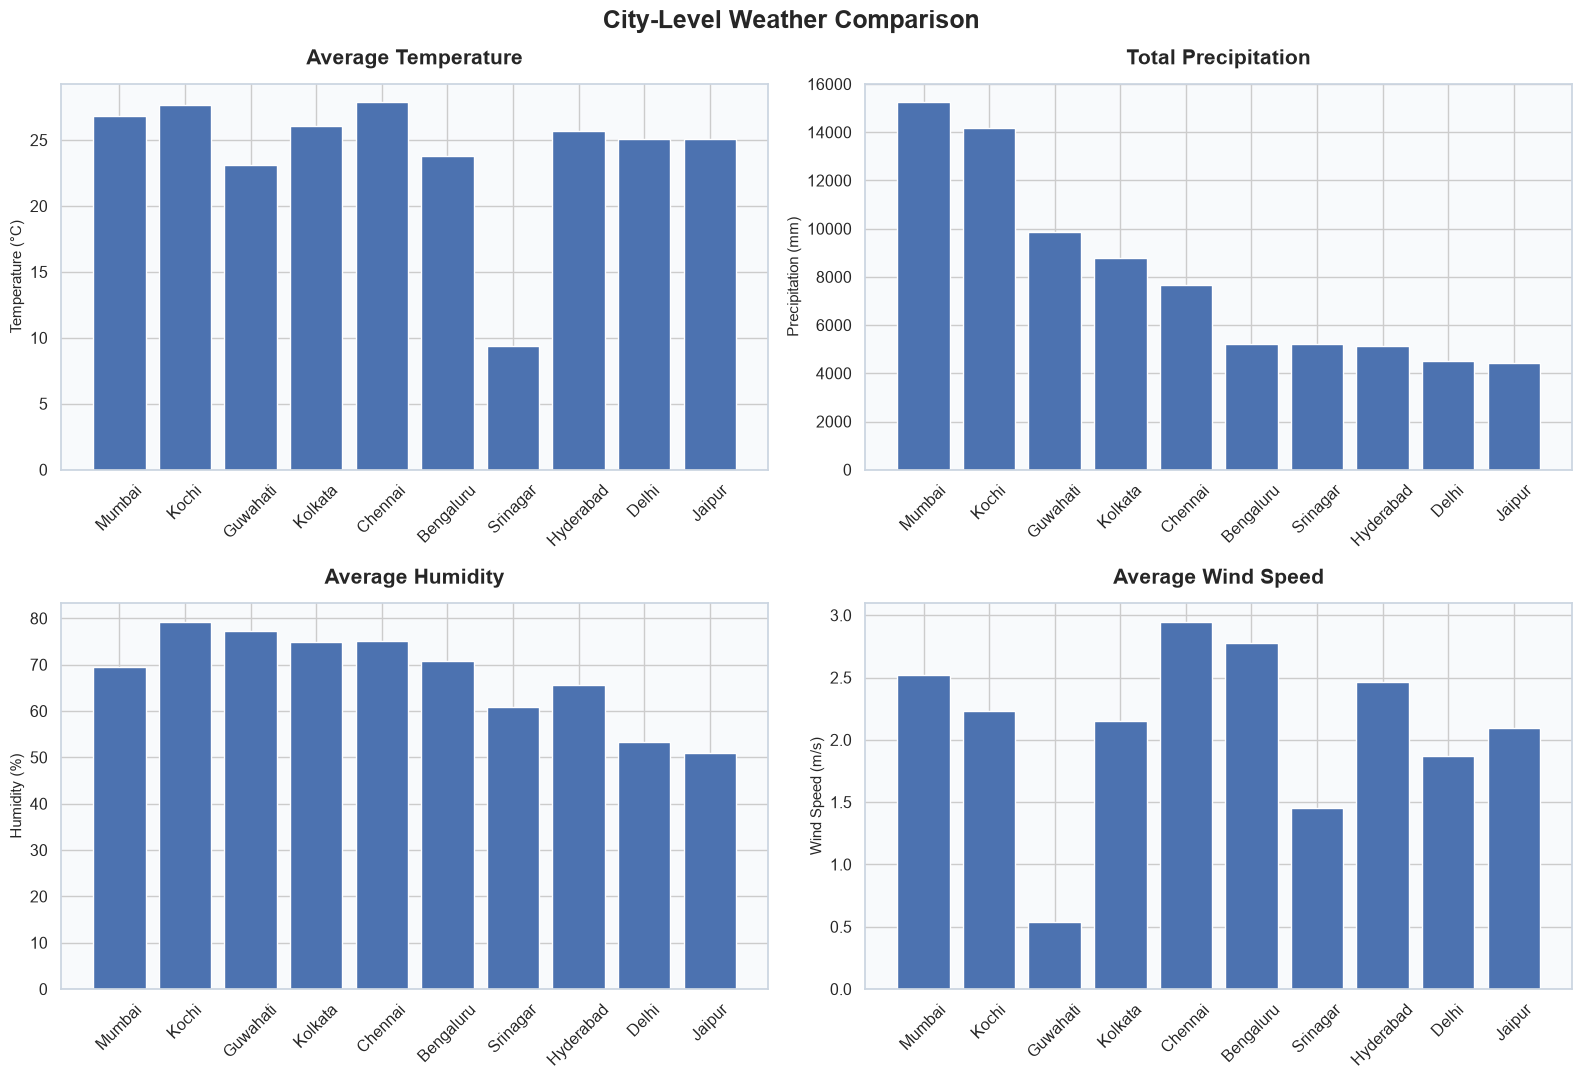

In [26]:
# 4 City-Level Weather Comparison

city_order = (
    df_clean.groupby("City")["PRECTOTCORR"]
    .sum()
    .sort_values(ascending=False)
    .index
)

fig, axes = plt.subplots(2, 2, figsize=(16, 11))

temp_city = df_clean.groupby("City")["T2M"].mean().reindex(city_order)
axes[0, 0].bar(temp_city.index, temp_city.values)
axes[0, 0].set_title("Average Temperature")
axes[0, 0].set_ylabel("Temperature (°C)")
axes[0, 0].tick_params(axis="x", rotation=45)

rain_city = df_clean.groupby("City")["PRECTOTCORR"].sum().reindex(city_order)
axes[0, 1].bar(rain_city.index, rain_city.values)
axes[0, 1].set_title("Total Precipitation")
axes[0, 1].set_ylabel("Precipitation (mm)")
axes[0, 1].tick_params(axis="x", rotation=45)

humidity_city = df_clean.groupby("City")["RH2M"].mean().reindex(city_order)
axes[1, 0].bar(humidity_city.index, humidity_city.values)
axes[1, 0].set_title("Average Humidity")
axes[1, 0].set_ylabel("Humidity (%)")
axes[1, 0].tick_params(axis="x", rotation=45)

wind_city = df_clean.groupby("City")["WS2M"].mean().reindex(city_order)
axes[1, 1].bar(wind_city.index, wind_city.values)
axes[1, 1].set_title("Average Wind Speed")
axes[1, 1].set_ylabel("Wind Speed (m/s)")
axes[1, 1].tick_params(axis="x", rotation=45)

fig.suptitle("City-Level Weather Comparison", fontsize=18, fontweight="bold")
plt.tight_layout()
plt.show()

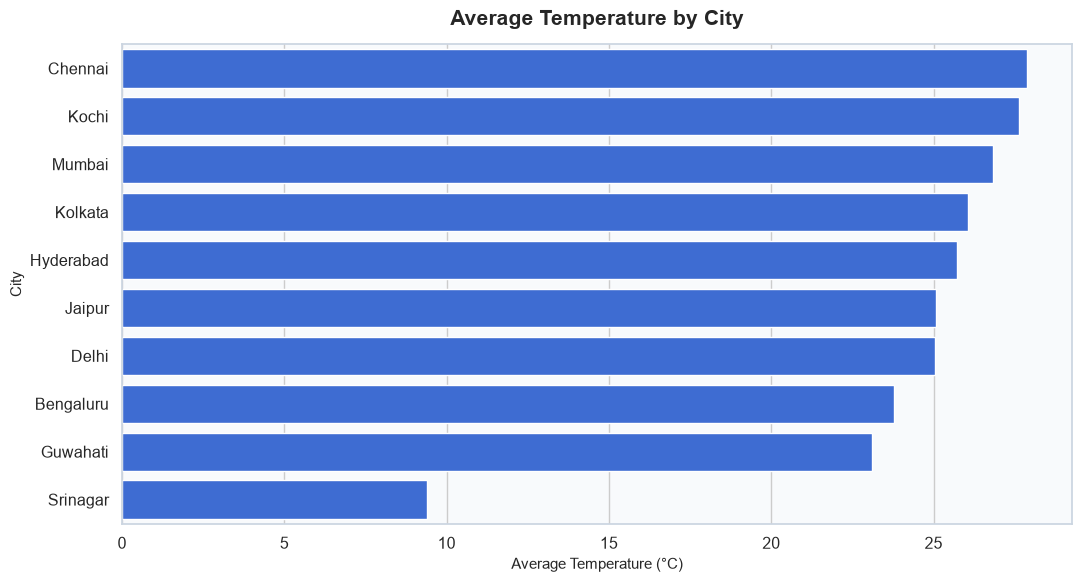

In [27]:
# 5 Average Temperature by City

city_temp = (
    df_clean.groupby("City", as_index=False)["T2M"]
    .mean()
    .sort_values("T2M", ascending=False)
)

plt.figure(figsize=(11, 6))
sns.barplot(
    data=city_temp,
    x="T2M",
    y="City",
    color=PROJECT_COLORS["primary"]
)
plt.title("Average Temperature by City")
plt.xlabel("Average Temperature (°C)")
plt.ylabel("City")
plt.tight_layout()
plt.show()

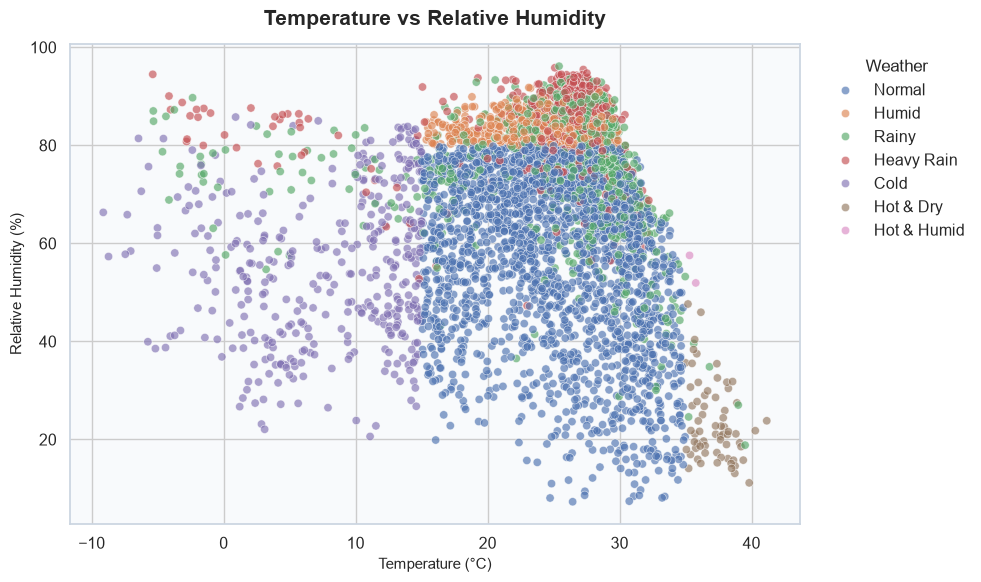

In [28]:
# 6 Temperature vs Relative Humidity

scatter_sample = df_clean.sample(
    min(5000, len(df_clean)),
    random_state=42
)

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=scatter_sample,
    x="T2M",
    y="RH2M",
    hue="Weather",
    alpha=0.65
)
plt.title("Temperature vs Relative Humidity")
plt.xlabel("Temperature (°C)")
plt.ylabel("Relative Humidity (%)")
plt.legend(
    title="Weather",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)
plt.tight_layout()
plt.show()

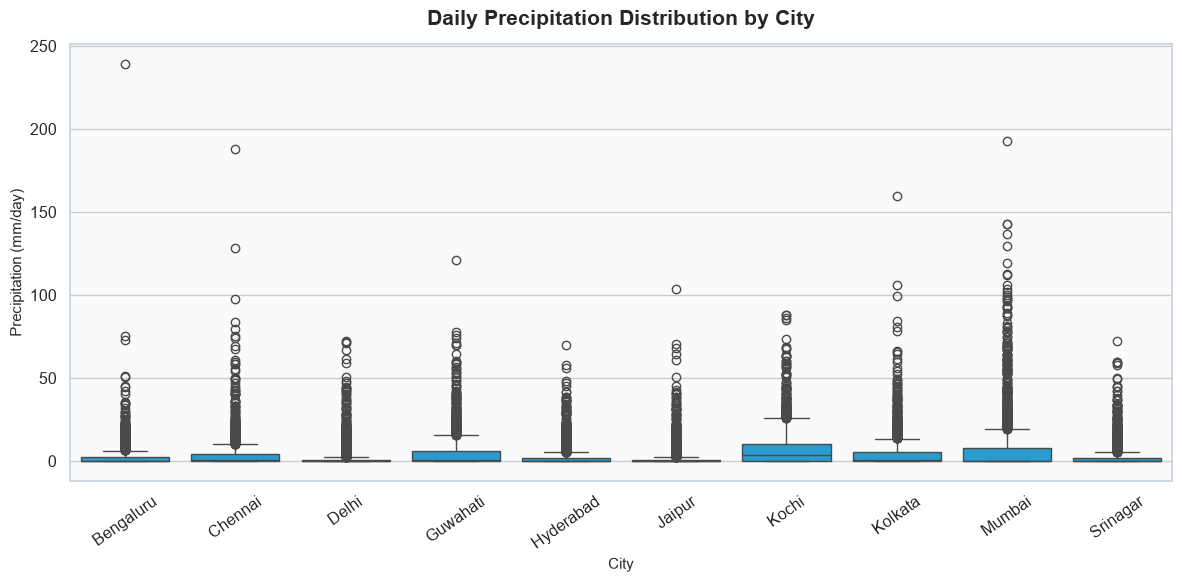

In [29]:
# 7 Daily Precipitation Distribution by City

plt.figure(figsize=(12, 6))
sns.boxplot(
    data=df_clean,
    x="City",
    y="PRECTOTCORR",
    color=PROJECT_COLORS["secondary"]
)
plt.title("Daily Precipitation Distribution by City")
plt.xlabel("City")
plt.ylabel("Precipitation (mm/day)")
plt.xticks(rotation=35)
plt.tight_layout()
plt.show()

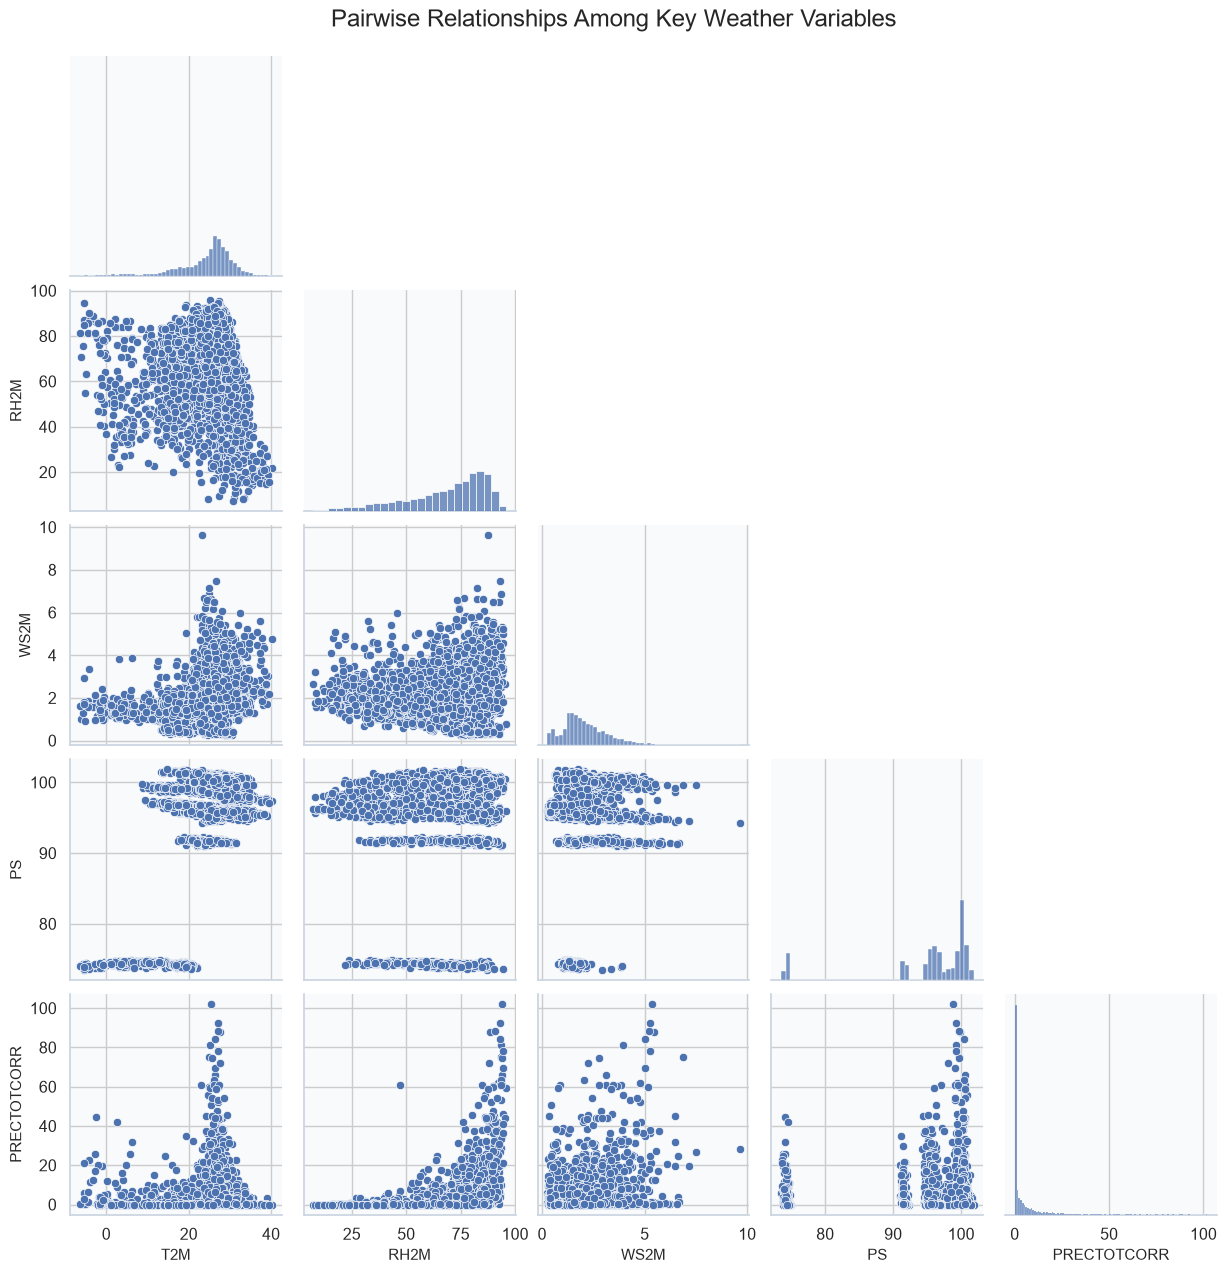

In [30]:
# 8 Pairwise Relationships Among Key Weather Variables
pairplot_cols = [
    "T2M",
    "RH2M",
    "WS2M",
    "PS",
    "PRECTOTCORR"
]

pairplot_sample = df_clean[pairplot_cols].sample(
    min(3000, len(df_clean)),
    random_state=42
)

sns.pairplot(
    pairplot_sample,
    diag_kind="hist",
    corner=True
)

plt.suptitle(
    "Pairwise Relationships Among Key Weather Variables",
    y=1.02
)
plt.show()

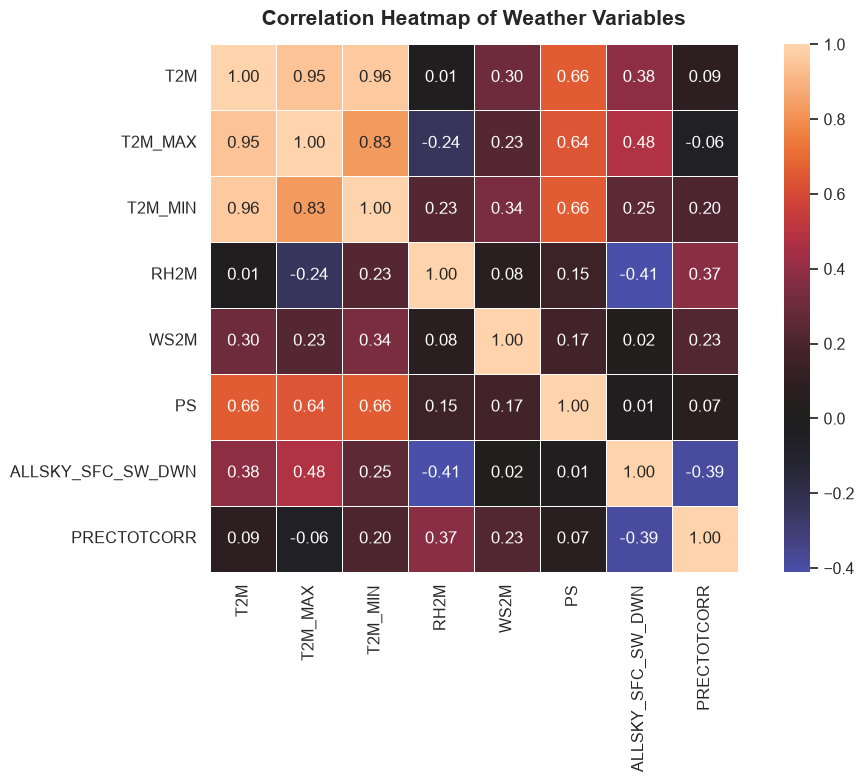

In [31]:
# 9 Correlation Heatmap of Weather Variables

corr_cols = [
    "T2M",
    "T2M_MAX",
    "T2M_MIN",
    "RH2M",
    "WS2M",
    "PS",
    "ALLSKY_SFC_SW_DWN",
    "PRECTOTCORR"
]

corr = df_clean[corr_cols].corr()

plt.figure(figsize=(11, 8))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    center=0,
    square=True,
    linewidths=0.5
)
plt.title("Correlation Heatmap of Weather Variables")
plt.tight_layout()
plt.show()

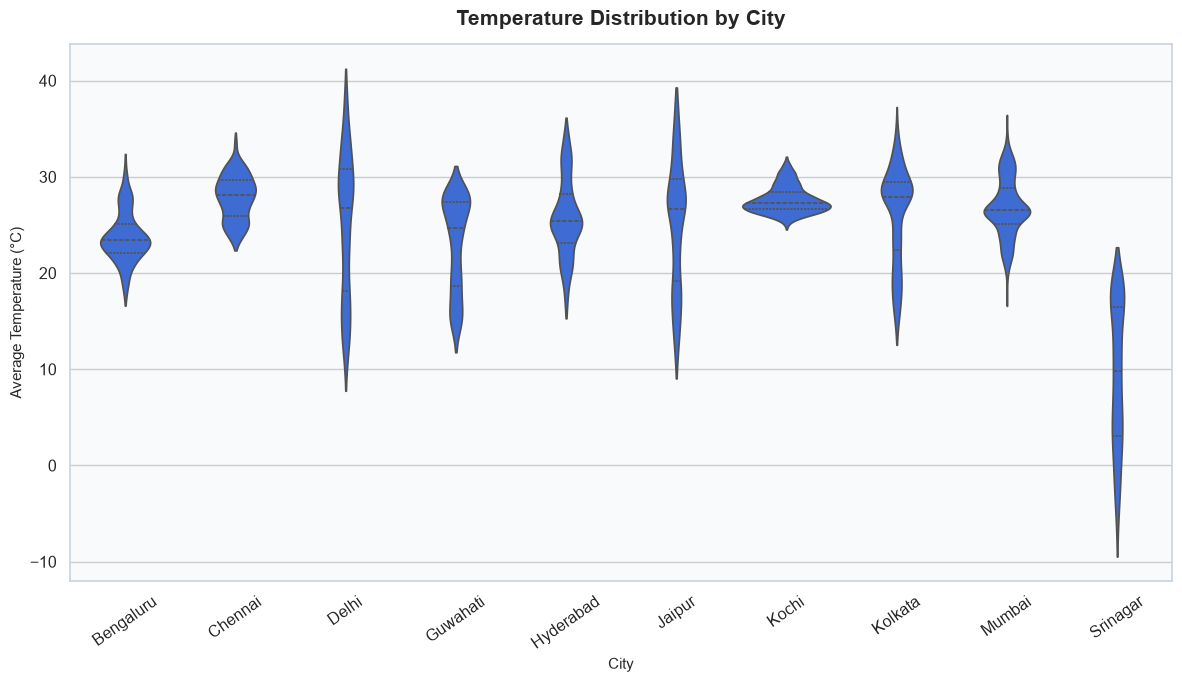

In [32]:
# 10 Temperature Distribution by City

plt.figure(figsize=(12, 7))
sns.violinplot(
    data=df_clean,
    x="City",
    y="T2M",
    inner="quartile",
    cut=0,
    color=PROJECT_COLORS["primary"]
)
plt.title("Temperature Distribution by City")
plt.xlabel("City")
plt.ylabel("Average Temperature (°C)")
plt.xticks(rotation=35)
plt.tight_layout()
plt.show()

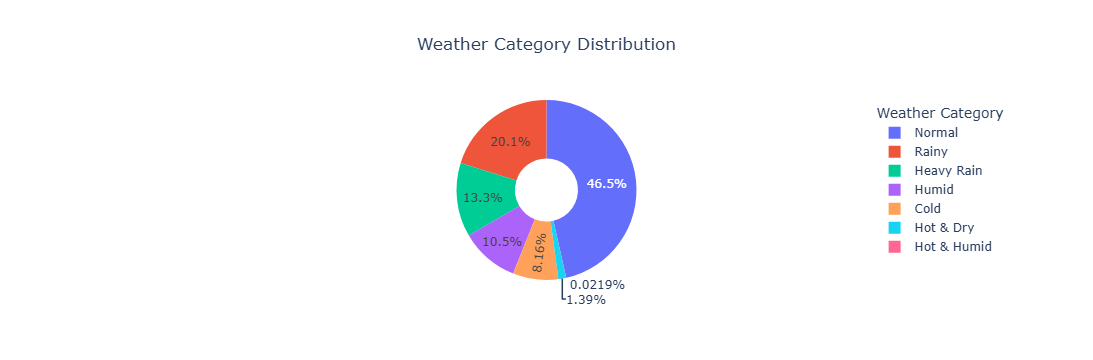

In [33]:
# 11 Weather Category Distribution

weather_counts = (
    df_clean["Weather"]
    .value_counts()
    .reset_index()
)
weather_counts.columns = ["Weather", "Count"]

fig = px.pie(
    weather_counts,
    names="Weather",
    values="Count",
    hole=0.35,
    title="Weather Category Distribution"
)

fig.update_layout(
    title_x=0.5,
    legend_title="Weather Category"
)

fig.show()

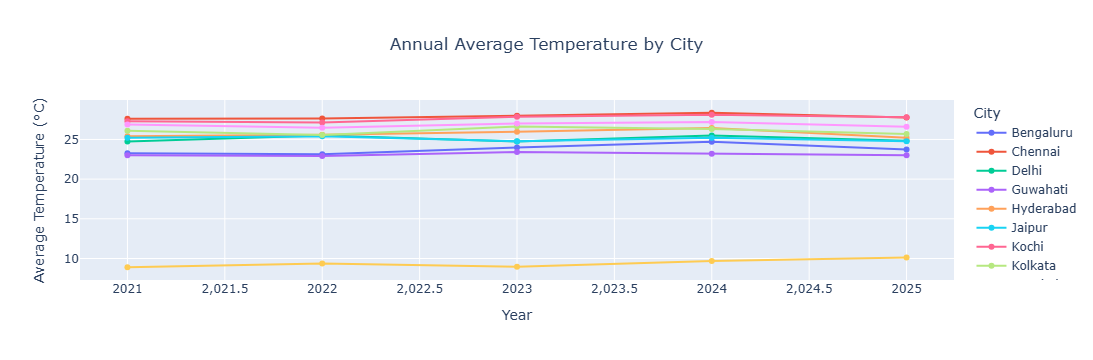

In [34]:
#12 Annual Average Temperature by City

fig = px.line(
    annual_summary,
    x="Year",
    y="Avg_Temperature",
    color="City",
    markers=True,
    title="Annual Average Temperature by City"
)

fig.update_layout(
    title_x=0.5,
    xaxis_title="Year",
    yaxis_title="Average Temperature (°C)",
    legend_title="City",
    hovermode="x unified"
)

fig.show()

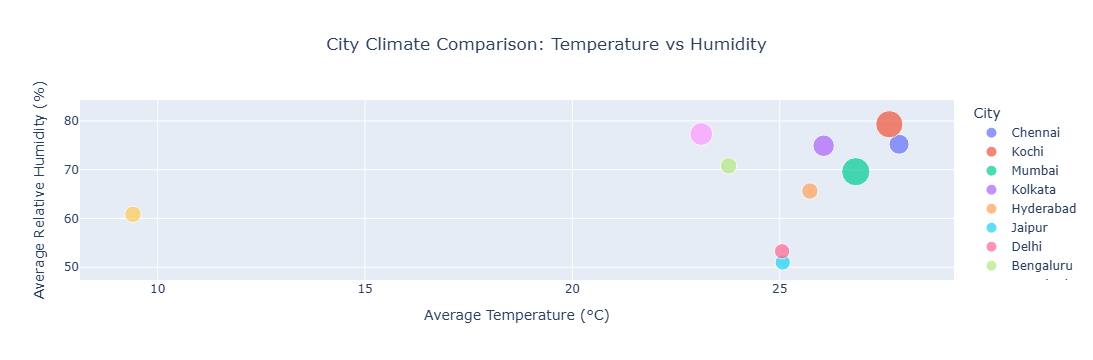

In [35]:
# 13 City Climate Comparison: Temperature vs Humidity

fig = px.scatter(
    city_summary,
    x="Avg_Temperature",
    y="Avg_Humidity",
    size="Total_Precipitation",
    color="City",
    hover_data=[
        "State",
        "Avg_Wind_Speed",
        "Avg_Solar_Radiation"
    ],
    title="City Climate Comparison: Temperature vs Humidity"
)

fig.update_layout(
    title_x=0.5,
    xaxis_title="Average Temperature (°C)",
    yaxis_title="Average Relative Humidity (%)"
)

fig.show()


# TASK 5 — Deeper Analysis & Derived Metrics


In [36]:
# Rainy-day and heavy-rain analysis

rain_analysis = (
    df_clean.groupby("City")
    .agg(
        Total_Days=("Date", "count"),
        Rainy_Days=("Rainy_Day", lambda x: (x == "Yes").sum()),
        Heavy_Rain_Days=("Heavy_Rain_Day", lambda x: (x == "Yes").sum()),
        Total_Rainfall_mm=("PRECTOTCORR", "sum"),
        Avg_Daily_Rainfall_mm=("PRECTOTCORR", "mean")
    )
    .reset_index()
)

rain_analysis["Rainy_Day_Percentage"] = (
    rain_analysis["Rainy_Days"] / rain_analysis["Total_Days"] * 100
)

rain_analysis["Heavy_Rain_Day_Percentage"] = (
    rain_analysis["Heavy_Rain_Days"] / rain_analysis["Total_Days"] * 100
)

display(
    rain_analysis
    .sort_values("Total_Rainfall_mm", ascending=False)
    .round(2)
)

,City,Total_Days,Rainy_Days,Heavy_Rain_Days,Total_Rainfall_mm,Avg_Daily_Rainfall_mm,Rainy_Day_Percentage,Heavy_Rain_Day_Percentage
8,Mumbai,1826,632,232,"15,250.31",8.35,34.61,12.71
6,Kochi,1826,1028,196,"14,174.44",7.76,56.30,10.73
3,Guwahati,1826,716,135,"9,849.75",5.39,39.21,7.39
7,Kolkata,1826,675,102,"8,796.98",4.82,36.97,5.59
1,Chennai,1826,620,80,"7,671.82",4.20,33.95,4.38
0,Bengaluru,1826,461,44,"5,222.33",2.86,25.25,2.41
9,Srinagar,1826,431,64,"5,210.48",2.85,23.60,3.50
4,Hyderabad,1826,427,61,"5,126.63",2.81,23.38,3.34
2,Delhi,1826,334,57,"4,509.96",2.47,18.29,3.12
5,Jaipur,1826,336,57,"4,440.75",2.43,18.40,3.12


In [37]:
# Seasonal comparison

season_order = ["Winter", "Summer", "Monsoon", "Post-Monsoon"]

season_summary = (
    df_clean.groupby("Season")
    .agg(
        Avg_Temperature=("T2M", "mean"),
        Avg_Humidity=("RH2M", "mean"),
        Avg_Wind_Speed=("WS2M", "mean"),
        Avg_Precipitation=("PRECTOTCORR", "mean"),
        Total_Precipitation=("PRECTOTCORR", "sum")
    )
    .reindex(season_order)
    .reset_index()
)

display(season_summary.round(2))

,Season,Avg_Temperature,Avg_Humidity,Avg_Wind_Speed,Avg_Precipitation,Total_Precipitation
0,Winter,18.59,63.60,1.77,1.00,"4,520.28"
1,Summer,27.00,53.63,2.17,2.80,"12,865.82"
2,Monsoon,26.77,78.23,2.52,8.49,"51,805.32"
3,Post-Monsoon,22.27,74.40,1.67,3.63,"11,062.03"


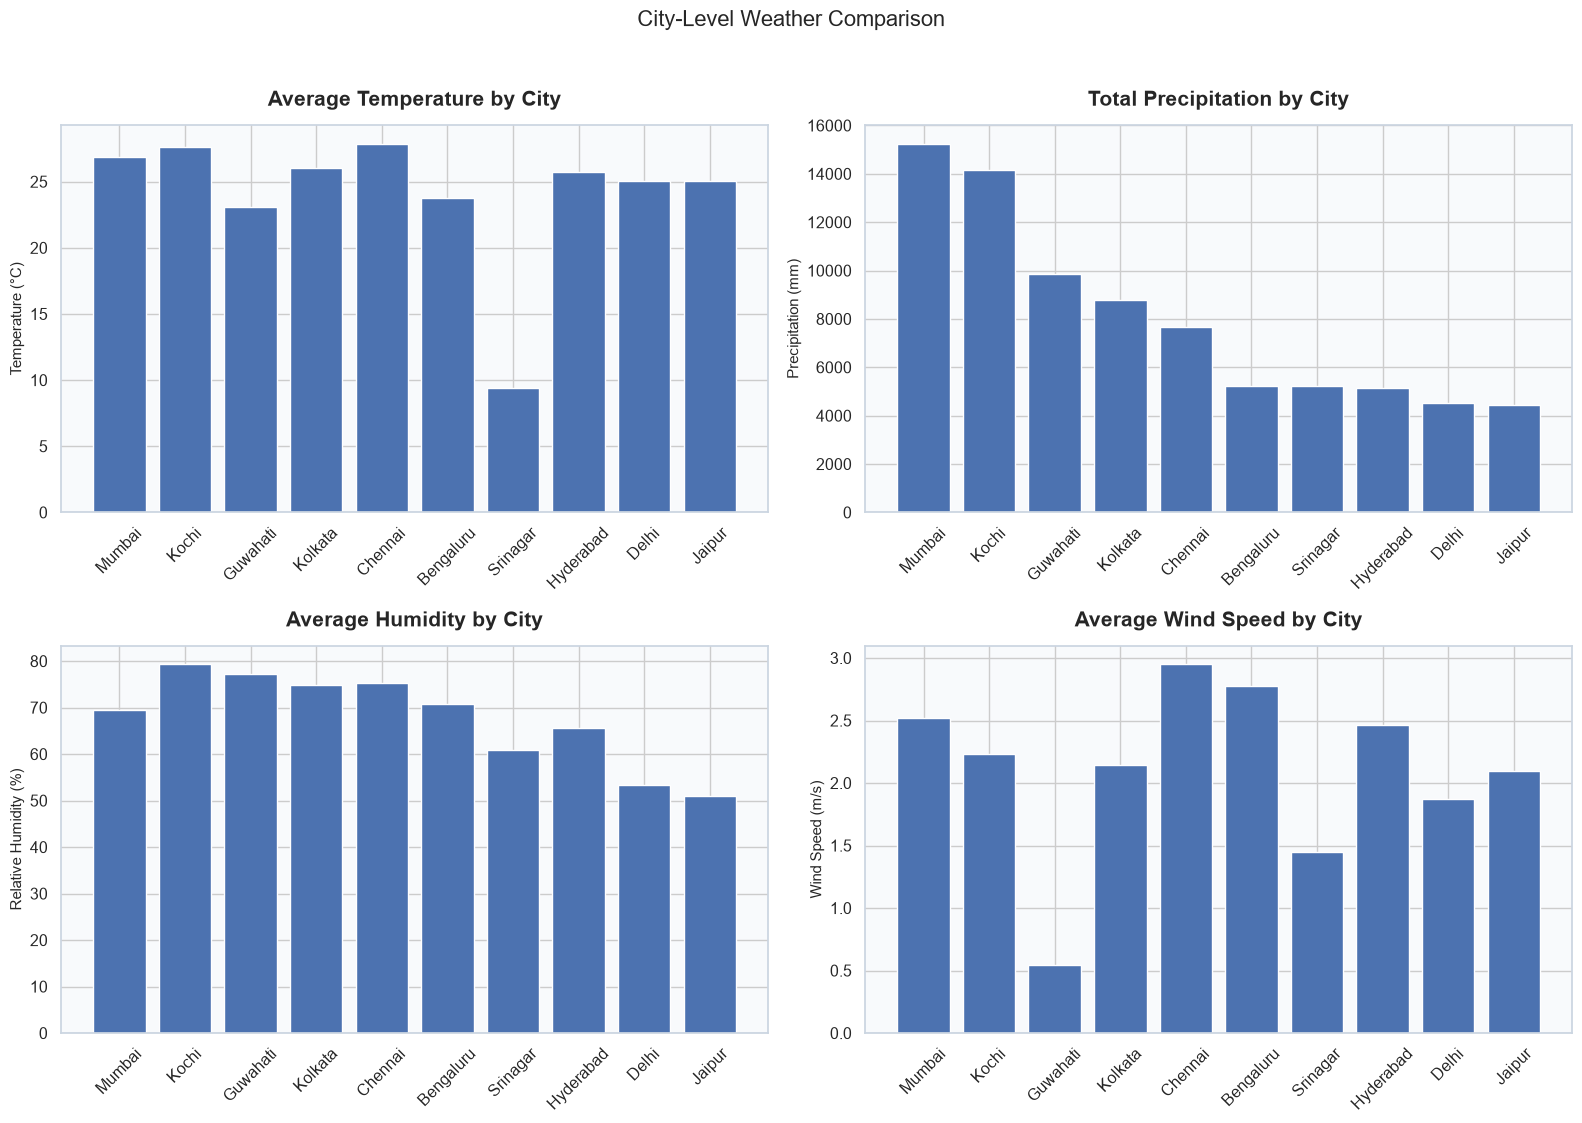

In [38]:
# Weather patterns by city — Subplots

city_order = (
    df_clean.groupby("City")["PRECTOTCORR"]
    .sum()
    .sort_values(ascending=False)
    .index
)

fig, axes = plt.subplots(2, 2, figsize=(16, 11))

# Subplot 1: Average temperature
temp_city = (
    df_clean.groupby("City")["T2M"]
    .mean()
    .reindex(city_order)
)
axes[0, 0].bar(temp_city.index, temp_city.values)
axes[0, 0].set_title("Average Temperature by City")
axes[0, 0].set_ylabel("Temperature (°C)")
axes[0, 0].tick_params(axis="x", rotation=45)

# Subplot 2: Total precipitation
rain_city = (
    df_clean.groupby("City")["PRECTOTCORR"]
    .sum()
    .reindex(city_order)
)
axes[0, 1].bar(rain_city.index, rain_city.values)
axes[0, 1].set_title("Total Precipitation by City")
axes[0, 1].set_ylabel("Precipitation (mm)")
axes[0, 1].tick_params(axis="x", rotation=45)

# Subplot 3: Average humidity
humidity_city = (
    df_clean.groupby("City")["RH2M"]
    .mean()
    .reindex(city_order)
)
axes[1, 0].bar(humidity_city.index, humidity_city.values)
axes[1, 0].set_title("Average Humidity by City")
axes[1, 0].set_ylabel("Relative Humidity (%)")
axes[1, 0].tick_params(axis="x", rotation=45)

# Subplot 4: Average wind speed
wind_city = (
    df_clean.groupby("City")["WS2M"]
    .mean()
    .reindex(city_order)
)
axes[1, 1].bar(wind_city.index, wind_city.values)
axes[1, 1].set_title("Average Wind Speed by City")
axes[1, 1].set_ylabel("Wind Speed (m/s)")
axes[1, 1].tick_params(axis="x", rotation=45)

fig.suptitle("City-Level Weather Comparison", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

In [39]:
# Identify top/bottom cities using several metrics

metrics = {
    "Highest average temperature": city_summary.loc[city_summary["Avg_Temperature"].idxmax(), ["City", "Avg_Temperature"]],
    "Lowest average temperature": city_summary.loc[city_summary["Avg_Temperature"].idxmin(), ["City", "Avg_Temperature"]],
    "Highest total precipitation": city_summary.loc[city_summary["Total_Precipitation"].idxmax(), ["City", "Total_Precipitation"]],
    "Lowest total precipitation": city_summary.loc[city_summary["Total_Precipitation"].idxmin(), ["City", "Total_Precipitation"]],
    "Highest average humidity": city_summary.loc[city_summary["Avg_Humidity"].idxmax(), ["City", "Avg_Humidity"]],
    "Highest average wind speed": city_summary.loc[city_summary["Avg_Wind_Speed"].idxmax(), ["City", "Avg_Wind_Speed"]],
}

for label, values in metrics.items():
    print(f"{label}: {values.iloc[0]} ({values.iloc[1]:.2f})")

Highest average temperature: Chennai (27.88)
Lowest average temperature: Srinagar (9.40)
Highest total precipitation: Mumbai (15250.31)
Lowest total precipitation: Jaipur (4440.75)
Highest average humidity: Kochi (79.32)
Highest average wind speed: Chennai (2.95)


In [40]:
# Find strongest correlations with average temperature and precipitation

temperature_corr = (
    corr["T2M"]
    .drop("T2M")
    .sort_values(key=np.abs, ascending=False)
)

rain_corr = (
    corr["PRECTOTCORR"]
    .drop("PRECTOTCORR")
    .sort_values(key=np.abs, ascending=False)
)

print("Correlation with T2M:")
display(temperature_corr.to_frame("Correlation"))

print("\nCorrelation with PRECTOTCORR:")
display(rain_corr.to_frame("Correlation"))

Correlation with T2M:


,Correlation
T2M_MIN,0.96
T2M_MAX,0.95
PS,0.66
ALLSKY_SFC_SW_DWN,0.38
WS2M,0.30
PRECTOTCORR,0.09
RH2M,0.01



Correlation with PRECTOTCORR:


,Correlation
ALLSKY_SFC_SW_DWN,-0.39
RH2M,0.37
WS2M,0.23
T2M_MIN,0.20
T2M,0.09
PS,0.07
T2M_MAX,-0.06


# TASK 6 — Key Findings

The following cell automatically generates a concise findings summary from the cleaned dataset. These values should be used in the final project report/presentation.


In [41]:
# Automatically generate project findings

hottest = city_summary.loc[city_summary["Avg_Temperature"].idxmax()]
coolest = city_summary.loc[city_summary["Avg_Temperature"].idxmin()]
wettest = city_summary.loc[city_summary["Total_Precipitation"].idxmax()]
driest = city_summary.loc[city_summary["Total_Precipitation"].idxmin()]
humid_city = city_summary.loc[city_summary["Avg_Humidity"].idxmax()]

wettest_month = monthly_summary.loc[
    monthly_summary["Total_Precipitation"].idxmax()
]
hottest_month = monthly_summary.loc[
    monthly_summary["Avg_Temperature"].idxmax()
]

print("KEY FINDINGS")
print("-" * 60)
print(
    f"1. Highest average temperature: {hottest['City']} "
    f"({hottest['Avg_Temperature']:.2f} °C)."
)
print(
    f"2. Lowest average temperature: {coolest['City']} "
    f"({coolest['Avg_Temperature']:.2f} °C)."
)
print(
    f"3. Highest total precipitation: {wettest['City']} "
    f"({wettest['Total_Precipitation']:.2f} mm)."
)
print(
    f"4. Lowest total precipitation: {driest['City']} "
    f"({driest['Total_Precipitation']:.2f} mm)."
)
print(
    f"5. Highest average humidity: {humid_city['City']} "
    f"({humid_city['Avg_Humidity']:.2f}%)."
)
print(
    f"6. Wettest month overall: {wettest_month['Month_Name']} "
    f"({wettest_month['Total_Precipitation']:.2f} mm)."
)
print(
    f"7. Warmest month overall: {hottest_month['Month_Name']} "
    f"({hottest_month['Avg_Temperature']:.2f} °C)."
)

print("\nWeather category distribution:")
display(
    df_clean["Weather"]
    .value_counts()
    .rename_axis("Weather")
    .reset_index(name="Days")
)

KEY FINDINGS
------------------------------------------------------------
1. Highest average temperature: Chennai (27.88 °C).
2. Lowest average temperature: Srinagar (9.40 °C).
3. Highest total precipitation: Mumbai (15250.31 mm).
4. Lowest total precipitation: Jaipur (4440.75 mm).
5. Highest average humidity: Kochi (79.32%).
6. Wettest month overall: Jul (17308.55 mm).
7. Warmest month overall: May (28.64 °C).

Weather category distribution:


,Weather,Days
0,Normal,8486
1,Rainy,3678
2,Heavy Rain,2430
3,Humid,1918
4,Cold,1490
5,Hot & Dry,254
6,Hot & Humid,4


# TASK 7 — Conclusion & Recommendations

## Conclusion
The analysis provides a five-year view of weather variability across ten Indian cities. City-level comparisons show that temperature, humidity, precipitation, and wind conditions differ substantially by location, while monthly and seasonal analysis highlights recurring climate patterns.

## Recommendations
1. Use city-specific rather than single national averages when interpreting weather conditions.
2. Use monthly/seasonal patterns for planning agriculture, tourism, transportation, and outdoor activities.
3. Monitor heavy-rain days separately from average rainfall because extreme precipitation can create disproportionate impacts.
4. Combine weather observations with crop, health, traffic, or energy datasets for a stronger predictive analytics project.
5. For future work, develop forecasting models for temperature or rainfall and evaluate them using appropriate time-series validation.

# Annual Weather Summary (2021–2025)

## The weather data across major Indian cities shows clear patterns in temperature, rainfall, and humidity.

## Temperature Trends:  
**Chennai** consistently records the highest average temperatures (around 27–28 °C), while **Srinagar** remains the coldest city (8–10 °C). Other cities like Kochi, Mumbai, and Hyderabad stay warm year-round, averaging 25–28 °C.

## Rainfall Patterns:  
**Kochi** and **Mumbai** are the rainiest cities, with Kochi reaching up to **3,386.65** mm in 2021 and Mumbai crossing **3,342.62** mm in 2025. Jaipur and Delhi are relatively dry, often below 1,000 mm annually. **Guwahati** also shows high rainfall, especially in **2022** (2,349.81 mm).

## Humidity Levels:  
**Kochi** leads in humidity every year (around 79–81%), followed closely by Guwahati and Chennai. Jaipur and Delhi remain the driest, with humidity levels around 50%.

## Yearly Highlights:
**2021:** Kochi had the highest rainfall (3,386.65 mm), while Srinagar was the coldest (8.90 °C).

**2022:** Guwahati saw peak rainfall (2,349.81 mm), and Chennai stayed hot (27.65 °C).

**2023:** Mumbai’s rainfall dropped to 2,660.87 mm, while Kochi remained humid (76.9%).

**2024:** Chennai reached its hottest average (28.36 °C), and Kochi stayed wet (2,708.31 mm).

**2025:** Mumbai recorded its highest rainfall (3,342.62 mm), while Srinagar warmed slightly to 10.12 °C.

## Key Takeaways
**Hottest city: Chennai (avg. ~28 °C),**
**Coldest city: Srinagar (avg. ~9–10 °C),**
**Wettest cities: Kochi & Mumbai,**
**Driest cities: Jaipur & Delhi,**
**Most humid: Kochi (~80%),**
**Least humid: Jaipur & Delhi (~50%)**

# TASK 8 — Export Cleaned Dataset & Summary Tables

In [42]:
# Export final analytical datasets

df_clean.to_csv("weather_cleaned_final.csv", index=False)
city_summary.to_csv("city_weather_summary.csv", index=False)
annual_summary.to_csv("annual_weather_summary.csv", index=False)
monthly_summary.to_csv("monthly_weather_summary.csv", index=False)
rain_analysis.to_csv("city_rainfall_analysis.csv", index=False)
season_summary.to_csv("seasonal_weather_summary.csv", index=False)

print("Files exported successfully:")
for filename in [
    "weather_cleaned_final.csv",
    "city_weather_summary.csv",
    "annual_weather_summary.csv",
    "monthly_weather_summary.csv",
    "city_rainfall_analysis.csv",
    "seasonal_weather_summary.csv"
]:
    print("✓", filename)

Files exported successfully:
✓ weather_cleaned_final.csv
✓ city_weather_summary.csv
✓ annual_weather_summary.csv
✓ monthly_weather_summary.csv
✓ city_rainfall_analysis.csv
✓ seasonal_weather_summary.csv
